# Maryland Automotive Industry : Chapter 4 - ARIMA Models
Total cars sold and real value of cars sold have been proven to move very strongly between one another until 2020 this was when Covid-19 impacted the global supply chains and the average pricee of cars sky rocketed. By splitting up the data into ne and used total cars sold it can be a more accurate prediction of these models that move independently to one another and will have different parameters influencing them at different levels.
#### New Cars Sold 
New cars have a higher average price but are less frequent within the industry. New cars also had a much bigger impact post 2020 because of the supply chain disruptions that were present that led to the number of battery packs, circuit chargers and other essential car parts that were usually used in production were haulted. 

#### Used Cars Sold
Used cars have a lower average price but take up about 2/3's of the sales of cars within Maryland. Used cars were not distrupted by the supply chain issues that took place but the average price of these cars did increase as a result in the rise of new cars sold resulting the average price of total cars growing which was the reason fo r the value of cars sold following 2020 having a steady growth while the total cars sold decreased. This will be looked at more.

### Import Packages

In [2]:
import pandas as pd # for dataframe
import numpy as np # for mathematical

In [ ]:
# import evaluation packages
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [7]:
# import arima packages
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [8]:
# import grid spec
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

### Import Data
Using the data that has had irregularities removed and has been deseasonalised will be best to focus on the movements of the data rather than the individual sales that happen from month to month.

In [12]:
irregular_data = pd.read_csv('/Users/ben_nicholson/Visual_Code_Projects/Personal_Projects/Maryland Automotive Industry/preprocessed_datasets/seasonal_decomposition/irr_removed_sales_data.csv')
irregular_data

,date,total_cars_sold,new_cars_sold,used_cars_sold,real_value_cars_sold,real_new_value_cars_sold,real_used_value_cars_sold
0,2002-01-31,81033,31106,49927,1983276860,1311790064,671486797
1,2002-02-28,78502,27520,50982,1779268812,1152499583,626769229
2,2002-03-31,93019,34225,58794,2118906951,1393518250,725388702
3,2002-04-30,96269,36452,59817,2203087599,1457386731,745700868
4,2002-05-31,97936,37359,60577,2231843792,1470619476,761224317
...,...,...,...,...,...,...,...
259,2023-08-31,78601,25876,52725,2148818539,1232783817,916034722
260,2023-09-30,69278,23892,48043,1888005721,1139805538,748200184
261,2023-10-31,69248,23775,45473,1870599863,1127101054,743498810
262,2023-11-30,64980,22720,42260,1760750411,1064941698,695808714


In [3]:
deseasonalised_sales_data = pd.read_csv('/Users/ben_nicholson/Visual_Code_Projects/Personal_Projects/Maryland Automotive Industry/preprocessed_datasets/seasonal_decomposition/cyclical_data.csv')
deseasonalised_sales_data

,date,total_cars_sold,new_cars_sold,used_cars_sold,real_value_cars_sold,real_new_value_cars_sold,real_used_value_cars_sold
0,2002-01-31,89211.636364,32128.060606,57086.753788,2.040573e+09,1.306241e+09,7.343742e+08
1,2002-02-28,90198.318182,33388.787879,56808.071970,2.108439e+09,1.381781e+09,7.276463e+08
2,2002-03-31,85240.954545,33241.742424,51829.844697,2.047125e+09,1.373544e+09,6.709275e+08
3,2002-04-30,89819.590909,34646.378788,55176.390152,2.134552e+09,1.424029e+09,7.212525e+08
4,2002-05-31,92093.181818,34892.015152,57204.299242,2.153645e+09,1.424879e+09,7.377548e+08
...,...,...,...,...,...,...,...
259,2023-08-31,72335.545455,24075.833333,47990.662879,2.014189e+09,1.155990e+09,8.511289e+08
260,2023-09-30,67325.454545,22306.333333,47558.526515,1.808565e+09,1.067845e+09,7.368013e+08
261,2023-10-31,68829.045455,24225.878788,44748.708333,1.846941e+09,1.125836e+09,7.235529e+08
262,2023-11-30,74532.954545,26698.469697,48331.162879,1.941684e+09,1.188839e+09,7.534438e+08


### Import Functions

#### Adf Testing
- ADF Test
- Difference Data Until 95% confidence data is stationary

In [74]:
def adf_test(data):
    """Perform the ADF test to check for stationarity."""
    test_results = adfuller(data)
    adf_statistic = test_results[0]
    p_value = test_results[1]
    critical_values = test_results[4]

    print('ADF Statistic: ', adf_statistic)
    print('P-Value: ', p_value)
    print('Critical Values:')
    for thres, adf_stat in critical_values.items():
        print(f'\t{thres}: {adf_stat:.2f}')

    return p_value, adf_statistic, critical_values

In [76]:
def difference_until_stationary(data, max_diff=5, significance_level=0.05):
    """
    Applies differencing until the data is stationary based on the ADF test, 
    and plots the series before each differencing.
    
    Parameters:
    - data: Time series data (array-like).
    - max_diff: Maximum number of differences to apply (default is 5).
    - significance_level: The p-value threshold to determine stationarity (default is 0.05).
    
    Returns:
    - diff_data: The differenced data series.
    - d: The number of differences applied.
    """
    p_value, adf_stat, critical_values = adf_test(data)
    d = 0
    
    while p_value > significance_level and d < max_diff:
        # Plot the current state of the data
        plt.figure(figsize=(10, 4))
        plt.plot(data, label=f"Order of Differencing: {d}")
        plt.title(f"Time Series Data (Order of Differencing: {d})")
        plt.legend()
        plt.show()

        # Apply differencing
        d += 1
        data = np.diff(data, n=1)
        print(f"\nDifferencing Order: {d}")
        p_value, adf_stat, critical_values = adf_test(data)
    
    # Final plot after the last differencing
    plt.figure(figsize=(10, 4))
    plt.plot(data, label=f"Final Differencing (Order: {d})")
    plt.title(f"Time Series Data (Final Differencing Order: {d})")
    plt.legend()
    plt.show()
    
    if p_value > significance_level:
        print(f"\nWarning: The data is not stationary after {d} differences.")
    else:
        print(f"\nThe series became stationary after {d} differences.")
    
    return data, d

#### ARIMA Testing

In [133]:
def arima_analysis(data, sa_data):

    # Differencing until stationary
    differenced_data, d = difference_until_stationary(data)
    differenced_sa_data, D = difference_until_stationary(sa_data)

    # Create the overall figure and GridSpec
    fig = plt.figure(figsize=(14,8))
    gs = GridSpec(4, 8, figure=fig)

    # Original data plot
    ax_o_data = fig.add_subplot(gs[0:2, 0:5])
    ax_o_data.plot(data)
    ax_o_data.set_title('Original Data')

    # ACF plot for original data
    ax_o_acf = fig.add_subplot(gs[0:1, 5:8])
    plot_acf(data, ax=ax_o_acf, lags=5)
    ax_o_acf.set_title('ACF of Original Data')

    # PACF plot for original data
    ax_o_pacf = fig.add_subplot(gs[1:2, 5:8])
    plot_pacf(data, ax=ax_o_pacf, lags=5)
    ax_o_pacf.set_title('PACF of Original Data')

    # Seasonally Adjusted data plot
    ax_sa_data = fig.add_subplot(gs[2:4, 0:5])
    ax_sa_data.plot(sa_data)
    ax_sa_data.set_title('Seasonally Adjusted Data')

    # ACF plot for seasonally adjusted data
    ax_sa_acf = fig.add_subplot(gs[2:3, 5:8])
    plot_acf(sa_data, ax=ax_sa_acf, lags=5)
    ax_sa_acf.set_title('ACF of Seasonally Adjusted Data')

    # PACF plot for seasonally adjusted data
    ax_sa_pacf = fig.add_subplot(gs[3:4, 5:8])
    plot_pacf(sa_data, ax=ax_sa_pacf, lags=5)
    ax_sa_pacf.set_title('PACF of Seasonally Adjusted Data')

    # Adjust layout
    plt.tight_layout()
    plt.show()

    return d, D

## New Cars Sold ARIMA Modeling
Use original cars sold to identify pdq
Use deseasonalised cars sold to identify PDQ

The deseasonalised data has been found in a previous chapter where manul deseasonalisation took place by removing irregularities then lookinat the average price of cars sold

ADF Statistic:  -1.6083521007561319
P-Value:  0.47939674350455996
Critical Values:
	1%: -3.46
	5%: -2.87
	10%: -2.57


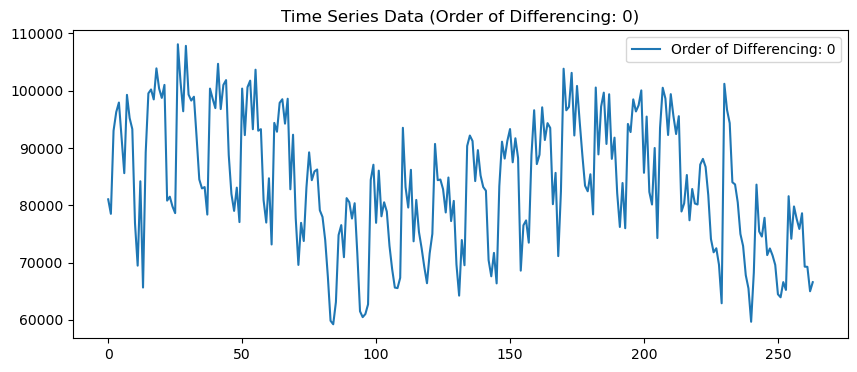


Differencing Order: 1
ADF Statistic:  -3.8881822828670867
P-Value:  0.0021235610514762433
Critical Values:
	1%: -3.46
	5%: -2.87
	10%: -2.57


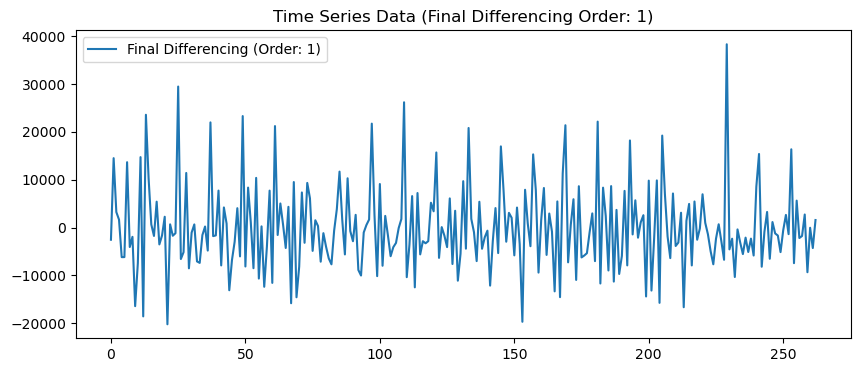


The series became stationary after 1 differences.
ADF Statistic:  -1.614469589866946
P-Value:  0.4756298443507242
Critical Values:
	1%: -3.46
	5%: -2.87
	10%: -2.57


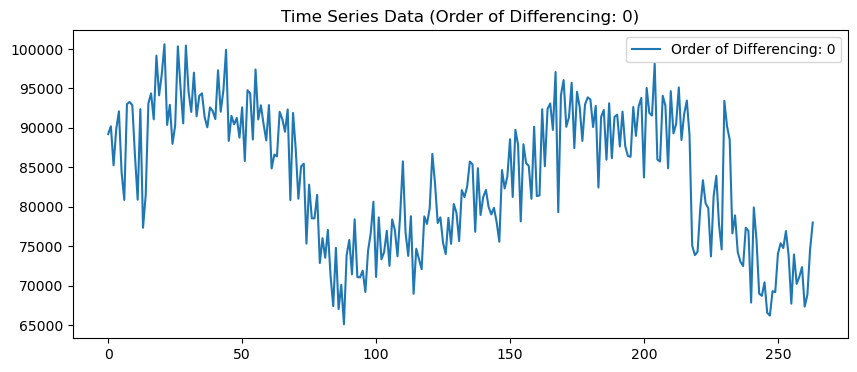


Differencing Order: 1
ADF Statistic:  -3.94449601792032
P-Value:  0.0017307210838064123
Critical Values:
	1%: -3.46
	5%: -2.87
	10%: -2.57


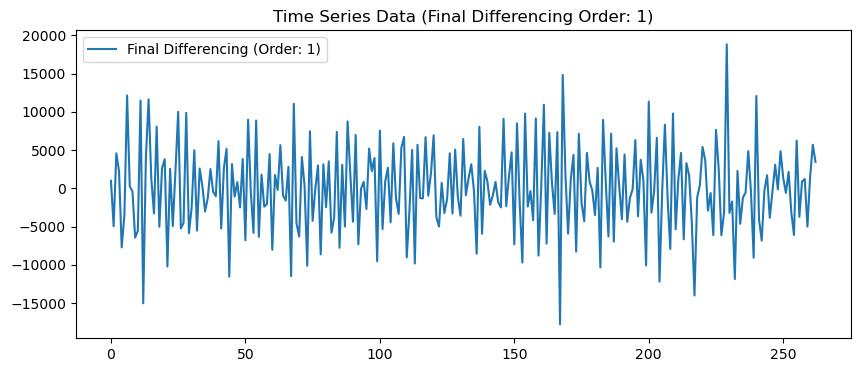


The series became stationary after 1 differences.


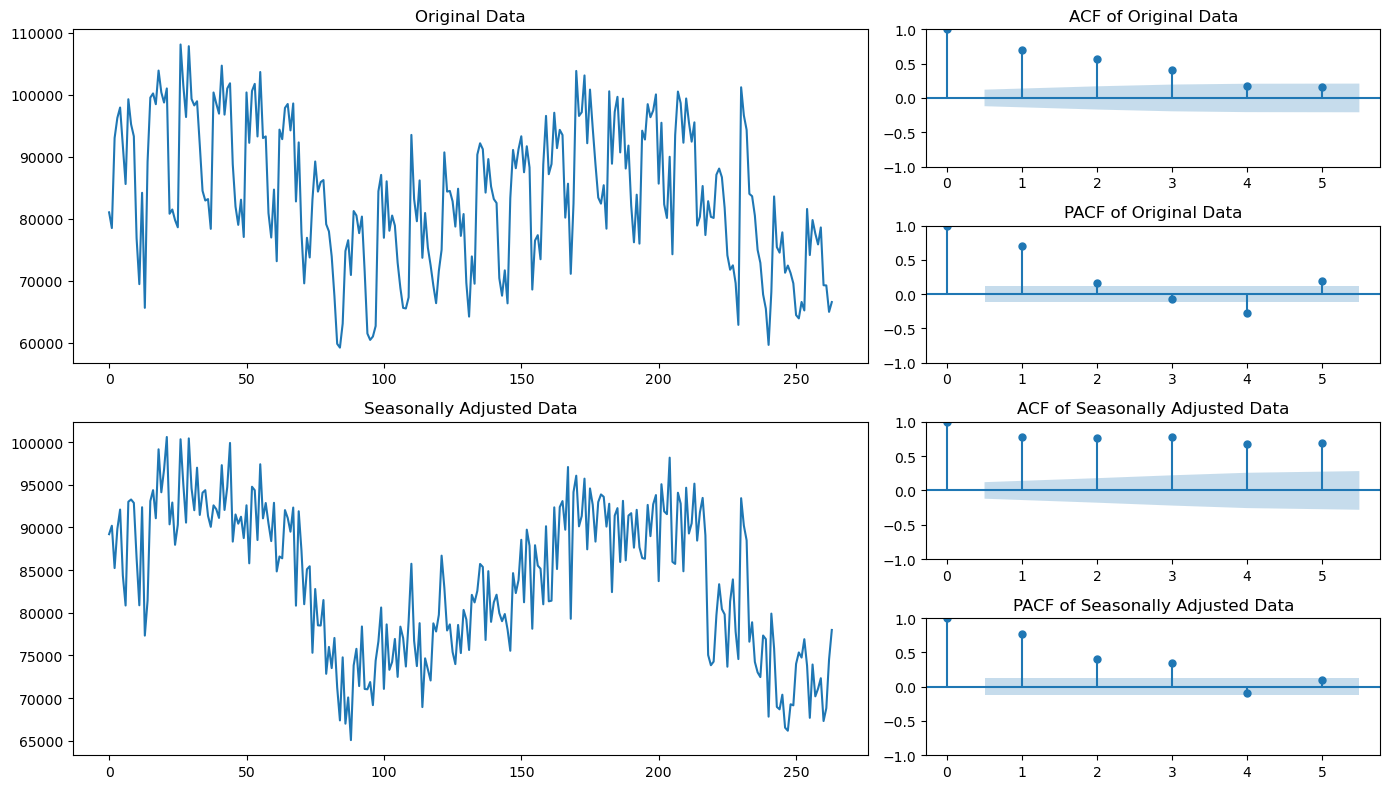

(1, 1)

In [134]:
arima_analysis(irregular_data['total_cars_sold'],deseasonalised_sales_data['total_cars_sold'])